# Brain-to-Text Metrics v2

This notebook evaluates NeuroVLM brain-to-text generation separately from text-to-brain. It keeps the semantic metrics from `new_neuropvlm_metrics_v2`, removes the cleaned abstract branch, adds Recall@1 retrieval, and adds network label accuracy for the Networks test set.

This notebook is configured to run the full available networks, PubMed test, and NeuroVault evaluation sets by default. For fast iteration, set `MAX_B2T` to a small integer.

In [1]:
import os
import hashlib
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util as st_util
from transformers import AutoModel, AutoTokenizer


In [2]:
LLM_BACKEND = "huggingface"
LLM_MODEL = "qwen2.5:7b-instruct"
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"
MINILM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MPNET_MODEL = "sentence-transformers/all-mpnet-base-v2"
B2T_RANDOM_EVIDENCE_N_SAMPLES = 25
B2T_RANDOM_EVIDENCE_SEED = 13

MAX_B2T = None        # full available networks, PubMed test, and NeuroVault sets
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True
RUN_GENERATED_TEXT = False  # slow LLM/BERTScore generated-text evaluation

B2T_TOP_K = 5
B2T_SIM_THR = 0.35
B2T_DATASETS = ["llm_neuro_terms", "kg_mesh", "cogatlas"]
OUTPUT_DIR = Path("docs/03_evaluation/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
nvlm = NeuroVLM()
B2T_ENCODER_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
_st_model = SentenceTransformer(MINILM_MODEL, device=B2T_ENCODER_DEVICE)
_mpnet_model = SentenceTransformer(MPNET_MODEL, device=B2T_ENCODER_DEVICE)
print(f"Ready. Sentence encoders on {B2T_ENCODER_DEVICE}.")


Ready. Sentence encoders on cpu.


In [4]:
def load_network_test_set_labels_table():
    try:
        return load_dataset("network_test_set_labels"), "huggingface:neurovlm/embedded_text/network_test_set_labels.csv"
    except Exception as hf_error:
        candidates = [
            Path("network_test_set_labels.csv"),
            Path("docs/03_evaluation/network_test_set_labels.csv"),
            Path.cwd() / "network_test_set_labels.csv",
            Path.cwd() / "docs/03_evaluation/network_test_set_labels.csv",
        ]
        for candidate in candidates:
            if candidate.exists():
                return pd.read_csv(candidate), str(candidate.resolve())
        raise FileNotFoundError(
            "Could not load network_test_set_labels.csv from Hugging Face or local paths. "
            "Upload it to neurovlm/embedded_text as network_test_set_labels.csv. "
            f"Hugging Face error: {hf_error}"
        )


network_labels_df, NETWORK_TEST_SET_SOURCE = load_network_test_set_labels_table()
network_labels_df = network_labels_df[network_labels_df["network_key"] != "unknown"].copy()

# One row per canonical network, derived from the network test-set CSV.
network_info = (
    network_labels_df
    .sort_values(["network_key", "raw_network_label"])
    .groupby("network_key", as_index=False)
    .agg(
        display=("network_name", "first"),
        short_definition=("short_definition", "first"),
        long_definition=("long_definition", "first"),
        mapped_terms=("mapped_terms", "first"),
        raw_aliases=("raw_network_label", lambda s: "; ".join(sorted(set(map(str, s))))),
    )
)

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_SOURCE}")
display(network_info[["network_key", "display", "short_definition"]])

Loaded 8 canonical network labels from huggingface:neurovlm/embedded_text/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [5]:
def _normalize_expected_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

all_net_latents = load_latent("networks_neuro")
network_label_rows = (
    network_labels_df
    .drop_duplicates("raw_network_label")
    .set_index("raw_network_label")
)

networks_data = {}
for atlas_name, atlas_latents in all_net_latents.items():
    if not hasattr(atlas_latents, "items"):
        continue
    for raw_label, latent in atlas_latents.items():
        if raw_label not in network_label_rows.index:
            continue
        row = network_label_rows.loc[raw_label]
        sample_name = f"{atlas_name}:{raw_label}"
        networks_data[sample_name] = {
            "latent": latent,
            "short_gt": _normalize_expected_text(row["short_definition"]),
            "long_gt": _normalize_expected_text(row["long_definition"]),
            "network_key": row["network_key"],
            "display": row["network_name"],
            "atlas": atlas_name,
            "raw_network_label": raw_label,
        }

print(f"Networks loaded: {len(networks_data)} labeled maps across {len(all_net_latents)} atlases")
display(pd.DataFrame([
    {"sample": name, "network_key": d["network_key"], "display": d["display"]}
    for name, d in networks_data.items()
]).head())

Networks loaded: 119 labeled maps across 10 atlases


,sample,network_key,display
0,Du:CG-OP,cingulo_opercular,Cingulo-Opercular
1,Du:DN-B,default_mode,Default Mode
2,Du:SMOT-B,motor,Motor
3,Du:AUD,auditory,Auditory
4,Du:PM-PPr,motor,Motor


In [6]:
# PubMed summaries dataset: use summary text as long-form ground truth.
# These summaries better match the desired B2T LLM output than full abstracts.
df_summaries = load_dataset("pubmed_summaries")
df_pubs = load_dataset("pubmed_text")

if "test" not in df_summaries.columns:
    raise ValueError("pubmed_summaries must include a boolean 'test' column for PubMed evaluation.")
df_test = df_summaries[df_summaries["test"].fillna(False).astype(bool)].reset_index(drop=True)

_pmid_col = "pmid" if "pmid" in df_test.columns else df_test.columns[0]
_summary_col = "summary" if "summary" in df_test.columns else "description"
_title_col = "title" if "title" in df_test.columns else ("name" if "name" in df_test.columns else None)

# Fill title from publications by PMID if summaries do not carry title/name.
_pub_pmid_col = "pmid" if "pmid" in df_pubs.columns else df_pubs.columns[0]
_pub_title_col = "name" if "name" in df_pubs.columns else ("title" if "title" in df_pubs.columns else None)
pub_title_lookup = {}
if _pub_title_col is not None:
    pub_title_lookup = (
        df_pubs
        .assign(_pmid_key=lambda df: df[_pub_pmid_col].astype(str))
        .drop_duplicates("_pmid_key")
        .set_index("_pmid_key")[_pub_title_col]
        .astype(str)
        .to_dict()
    )

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids).astype(str)
summary_text_latents, summary_latent_pmids = load_latent("pubmed_summaries")
summary_latent_pmids = np.asarray(summary_latent_pmids).astype(str)
summary_latent_by_pmid = {pmid: summary_text_latents[i] for i, pmid in enumerate(summary_latent_pmids)}

test_pmids = df_test[_pmid_col].astype(str).values
mask = np.isin(pubmed_pmids, test_pmids)
aligned_latents = pubmed_latents[mask]
aligned_pmids = pubmed_pmids[mask]

pmid_to_row = (
    df_test
    .assign(_pmid_key=lambda df: df[_pmid_col].astype(str))
    .drop_duplicates("_pmid_key")
    .set_index("_pmid_key")
)

pubmed_data = []
missing_summary_latents = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    if pmid not in summary_latent_by_pmid:
        missing_summary_latents.append(pmid)
        continue
    row = pmid_to_row.loc[pmid]
    title = str(row[_title_col]) if _title_col is not None and _title_col in row.index else pub_title_lookup.get(pmid, "")
    summary = str(row[_summary_col]) if _summary_col in row.index else ""
    pubmed_data.append({
        "pmid": pmid,
        "latent": aligned_latents[i],
        "text_latent": summary_latent_by_pmid[pmid],
        "short_gt": title,
        "long_gt": summary,
    })

if missing_summary_latents:
    print(f"Skipped {len(missing_summary_latents):,} PubMed test papers without precomputed summary text latents.")
pubmed_eval = pubmed_data[:MAX_B2T] if MAX_B2T else pubmed_data
print(f"PubMed summary test samples: {len(pubmed_eval)} / {len(pubmed_data)}")
print(f"Summaries table rows: {len(df_summaries):,}; test rows: {len(df_test):,}")


PubMed summary test samples: 2987 / 2987
Summaries table rows: 30,826; test rows: 3,945


In [7]:
df_nv = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")
nv_text_latents = load_latent("neurovault_text")

_doi_pub = "doi" if "doi" in df_nv.columns else df_nv.columns[0]
_doi_meta = "doi" if "doi" in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title" if "title" in df_nv.columns else df_nv.columns[1]
_abs_nv = "abstract" if "abstract" in df_nv.columns else df_nv.columns[2]

@torch.no_grad()
def _project_precomputed_text_latents(text_latents, batch_size: int = 512) -> torch.Tensor:
    nvlm._ensure_projection_heads()
    x = torch.as_tensor(text_latents).float()
    if x.dim() == 1:
        x = x.unsqueeze(0)
    chunks = []
    for start in range(0, len(x), batch_size):
        z = nvlm._proj_head_text_infonce(x[start : start + batch_size].to(nvlm.device))
        chunks.append(F.normalize(z.float(), dim=1, eps=1e-8).detach().cpu())
    return torch.cat(chunks, dim=0)

@torch.no_grad()
def _project_precomputed_brain_latents(brain_latents, batch_size: int = 512) -> torch.Tensor:
    nvlm._ensure_projection_heads()
    x = torch.as_tensor(brain_latents).float()
    if x.dim() == 1:
        x = x.unsqueeze(0)
    chunks = []
    for start in range(0, len(x), batch_size):
        z = nvlm._proj_head_image(x[start : start + batch_size].to(nvlm.device))
        chunks.append(F.normalize(z.float(), dim=1, eps=1e-8).detach().cpu())
    return torch.cat(chunks, dim=0)

# Pick the NeuroVault image whose brain embedding is most similar to the paired
# publication text embedding, instead of taking the first image for each DOI.
nv_brain_shared = _project_precomputed_brain_latents(nv_latents)
nv_text_shared = _project_precomputed_text_latents(nv_text_latents)

neurovault_data = []
for text_idx, pub_row in df_nv.reset_index(drop=True).iterrows():
    if text_idx >= len(nv_text_latents):
        continue
    doi = pub_row[_doi_pub]
    img_indices = np.where((df_nv_meta[_doi_meta] == doi).values)[0]
    img_indices = np.asarray([idx for idx in img_indices if idx < len(nv_latents)], dtype=int)
    if len(img_indices) == 0:
        continue
    sims = nv_brain_shared[img_indices] @ nv_text_shared[text_idx : text_idx + 1].T
    best_img_idx = int(img_indices[int(torch.argmax(sims.squeeze()).item())])
    neurovault_data.append({
        "doi": doi,
        "latent": nv_latents[best_img_idx],
        "text_latent": nv_text_latents[text_idx],
        "short_gt": str(pub_row[_title_nv]),
        "long_gt": str(pub_row[_abs_nv]),
        "selected_image_index": best_img_idx,
        "n_candidate_images": int(len(img_indices)),
        "selected_image_text_similarity": float(sims.max().item()),
    })

neurovault_selection_df = pd.DataFrame([
    {
        "doi": d["doi"],
        "selected_image_index": d["selected_image_index"],
        "n_candidate_images": d["n_candidate_images"],
        "selected_image_text_similarity": d["selected_image_text_similarity"],
    }
    for d in neurovault_data
])
neurovault_selection_df.to_csv(OUTPUT_DIR / "b2t_neurovault_argmax_image_selection.csv", index=False)
neurovault_selection_df.to_json(OUTPUT_DIR / "b2t_neurovault_argmax_image_selection.json", orient="records", indent=2)

neurovault_eval = neurovault_data[:MAX_B2T] if MAX_B2T else neurovault_data
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_data)}")
print("NeuroVault image selection: argmax brain-image/shared-text similarity per DOI.")


NeuroVault samples: 312 / 312
NeuroVault image selection: argmax brain-image/shared-text similarity per DOI.


## Metric Helpers

`nvlm_sim` is a cosine similarity in NeuroVLM's shared latent space. A value around 0.33 can be meaningful because it is measured against a broad retrieval space, so the notebook plots it with empirical quartiles and a random-pair baseline rather than treating 1.0 as the only intuitive target.

In [8]:
def _semantic_sim(gen: str, gt: str) -> float:
    emb1 = _st_model.encode(gen, convert_to_tensor=True)
    emb2 = _st_model.encode(gt, convert_to_tensor=True)
    return float(st_util.cos_sim(emb1, emb2))


def _bertscore_single(generated: str, reference: str):
    p, r, f1 = bert_score(
        cands=[generated],
        refs=[reference],
        lang="en",
        model_type=BERTSCORE_MODEL,
        verbose=False,
    )
    return float(p[0]), float(r[0]), float(f1[0])


def _nvlm_latent_sim(brain_query_emb: torch.Tensor, generated: str) -> float:
    nvlm._ensure_projection_heads()
    with torch.no_grad():
        raw_emb = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw_emb.to(nvlm.device))
        z_text = F.normalize(z_text, dim=-1).cpu()
    z_brain = brain_query_emb.cpu()
    if z_brain.dim() == 1:
        z_brain = z_brain.unsqueeze(0)
    return float(F.cosine_similarity(z_brain, z_text))


def _format_context_summary(table):
    lines = []
    for _, row in table.iterrows():
        lines.append(f"[{row.get('dataset', '?')}] sim={row.get('cosine_similarity', float('nan')):.3f} | {row.get('title', '')}")
    return "\n".join(lines)


def _b2t_once(table, user_prompt, gt_text, max_tokens, brain_query_emb):
    generated = nvlm.generate_llm_response(
        backend=LLM_BACKEND,
        model_name=LLM_MODEL,
        table=table,
        user_prompt=user_prompt,
        max_new_tokens=max_tokens,
        verbose=False,
    )
    bert_p, bert_r, bert_f1 = _bertscore_single(generated, gt_text)
    return {
        "generated": generated,
        "gt_text": gt_text,
        "bert_p": bert_p,
        "bert_r": bert_r,
        "bert_f1": bert_f1,
        "sem_sim": _semantic_sim(generated, gt_text),
        "nvlm_sim": _nvlm_latent_sim(brain_query_emb, generated),
    }


def run_b2t(name, latent, short_gt, long_gt, short_prompt, long_prompt="", short_tokens=64, long_tokens=512, datasets=None):
    try:
        result = nvlm.brain(latent).to_text(datasets=datasets or B2T_DATASETS)
        all_table = result.top_k(B2T_TOP_K)
        table = all_table[all_table["cosine_similarity"] > B2T_SIM_THR]
        if table.empty:
            table = all_table
        if len(table) > B2T_TOP_K:
            table = table.nlargest(B2T_TOP_K, "cosine_similarity").reset_index(drop=True)

        records = []
        for mode, prompt, gt, tokens in [
            ("short", short_prompt, short_gt, short_tokens),
            ("long", long_prompt, long_gt, long_tokens),
        ]:
            rec = _b2t_once(table, prompt, gt, tokens, result.query_embeddings)
            rec.update({"name": name, "mode": mode, "context_summary": _format_context_summary(table)})
            records.append(rec)
        return records
    except Exception as e:
        print(f"[B2T error] {name}: {type(e).__name__}: {e}")
        traceback.print_exc()
        return []


SHORT_PROMPT_GENERAL = (
    "Reply with a single concise sentence (10-20 words) naming the main cognitive "
    "function or brain network. Output only that sentence."
)
SHORT_PROMPT_PUBMED = (
    "Generate only a paper title (6-12 words) for the neuroimaging study this "
    "brain activation pattern represents. Output the title only."
)
LONG_PROMPT = ""

In [9]:
def normalize_label_text(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", str(text).lower()).strip()


def _network_aliases(row):
    aliases = []
    for value in [row["display"], row.get("mapped_terms", ""), row.get("raw_aliases", "")]:
        aliases.extend([normalize_label_text(x) for x in str(value).split(";")])
    aliases.append(normalize_label_text(row["network_key"].replace("_", " ")))
    return [x for x in dict.fromkeys(aliases) if x]


NETWORK_LABEL_ROWS = network_info.to_dict("records")
NETWORK_ALIAS_MAP = {row["network_key"]: _network_aliases(row) for row in NETWORK_LABEL_ROWS}


def predict_network_label(text: str, min_semantic_margin=0.02):
    text_norm = normalize_label_text(text)
    alias_hits = []
    for key, aliases in NETWORK_ALIAS_MAP.items():
        for alias in aliases:
            if alias and re.search(rf"\b{re.escape(alias)}\b", text_norm):
                alias_hits.append((key, alias))
                break
    if len(alias_hits) == 1:
        return alias_hits[0][0], "alias", alias_hits[0][1], 1.0

    label_texts = [f"{row['display']}. {row['long_definition']}" for row in NETWORK_LABEL_ROWS]
    generated_emb = _st_model.encode(text, convert_to_tensor=True)
    label_emb = _st_model.encode(label_texts, convert_to_tensor=True)
    sims = st_util.cos_sim(generated_emb, label_emb).cpu().numpy().ravel()
    order = sims.argsort()[::-1]
    keys = [row["network_key"] for row in NETWORK_LABEL_ROWS]
    margin = float(sims[order[0]] - sims[order[1]]) if len(order) > 1 else float("nan")
    method = "semantic" if margin >= min_semantic_margin else "semantic_low_margin"
    best_row = NETWORK_LABEL_ROWS[order[0]]
    return keys[order[0]], method, best_row["display"], float(sims[order[0]])


def add_network_label_accuracy(df):
    out = df.copy()
    preds = out["generated"].apply(predict_network_label)
    out["pred_network_key"] = [p[0] for p in preds]
    out["label_match_method"] = [p[1] for p in preds]
    out["label_match_evidence"] = [p[2] for p in preds]
    out["label_match_score"] = [p[3] for p in preds]
    out["true_network_key"] = out["name"].map(lambda name: networks_data[name]["network_key"])
    out["network_label_correct"] = out["pred_network_key"] == out["true_network_key"]
    return out

## Retrieval Evidence Metrics

These analyses evaluate retrieval before any LLM generation. That keeps the metric tied to what the brain encoder ranks, rather than to how well the LLM writes from those ranked results.

- **Paper-level retrieval** is the canonical PubMed metric and is also applied to NeuroVault. It asks whether each brain embedding retrieves its paired paper text, with exact-paper and semantic-neighbor variants.
- **Network gold-term ranking** asks whether known network terms appear high in the ranked NeuroVLM term list. The notebook keeps the broad `llm_neuro_terms + kg_mesh + cogatlas` corpus; normalized k keeps this comparable to a network-CSV-only term corpus.

Generated text evaluation is kept later and is disabled by default because it is much slower.


### PubMed Retrieval Corpus

PubMed paper-level retrieval is the primary PubMed metric. This setting only controls the MeSH corpus used later if generated-text context is retrieved for PubMed examples.


In [10]:
INCLUDE_MOLECULAR_MESH = False
MESH_BRAIN_RANKABLE_NODE_TYPES = [
    "disorder",
    "anatomical_region",
    "biological_process",
    "cognitive_construct",
]
if INCLUDE_MOLECULAR_MESH:
    MESH_BRAIN_RANKABLE_NODE_TYPES.append("molecular")

PUBMED_B2T_DATASET = "kg_mesh_brain_rankable_plus_molecular" if INCLUDE_MOLECULAR_MESH else "kg_mesh_brain_rankable"
print(f"PubMed generated-text retrieval corpus: {PUBMED_B2T_DATASET}")
print(f"Allowed PubMed MeSH node types in that corpus: {MESH_BRAIN_RANKABLE_NODE_TYPES}")


PubMed generated-text retrieval corpus: kg_mesh_brain_rankable
Allowed PubMed MeSH node types in that corpus: ['disorder', 'anatomical_region', 'biological_process', 'cognitive_construct']


In [11]:
TERM_EVAL_NORMALIZED_KS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
TERM_RECALL_CURVE_NORMALIZED_KS = np.linspace(0.0, 1.0, 101)
B2T_TERM_EXAMPLE_TOP_K = 20
B2T_TERM_TOP_K = B2T_TERM_EXAMPLE_TOP_K
B2T_EVIDENCE_TOP_K = B2T_TOP_K
NETWORK_B2T_TERM_DATASETS = ["llm_neuro_terms", "kg_mesh", "cogatlas"]
B2T_TERM_DATASETS_BY_EVAL_DATASET = {
    "networks": NETWORK_B2T_TERM_DATASETS,
    "pubmed": [PUBMED_B2T_DATASET],
    "neurovault": NETWORK_B2T_TERM_DATASETS,
}
B2T_RETRIEVAL_TABLE_CACHE = {}


def normalize_term_text(text: str) -> str:
    text = str(text or "").lower()
    text = text.split("/")[0]
    return re.sub(r"[^a-z0-9]+", " ", text).strip()


def split_gold_terms(value) -> list[str]:
    if pd.isna(value):
        return []
    terms = []
    for chunk in re.split(r";|\n|\|", str(value)):
        term = chunk.strip()
        if term:
            terms.append(term)
    return terms


def terms_for_dataset(dataset_name: str) -> set[str]:
    df = load_dataset(dataset_name)
    if not isinstance(df, pd.DataFrame):
        return set()
    for col in ["term", "title", "name", "label"]:
        if col in df.columns:
            return {normalize_term_text(x) for x in df[col].dropna().astype(str)}
    return set()


def network_gold_terms(sample_name: str) -> list[str]:
    d = networks_data[sample_name]
    label_rows = network_labels_df[network_labels_df["raw_network_label"].astype(str) == str(d["raw_network_label"])]
    if label_rows.empty:
        label_rows = network_labels_df[network_labels_df["network_key"] == d["network_key"]]
    terms = []
    for col in ["mapped_terms", "region_terms", "cognitive_terms"]:
        if col in label_rows.columns:
            for value in label_rows[col].dropna().tolist():
                terms.extend(split_gold_terms(value))
    return list(dict.fromkeys(terms))


def pubmed_gold_terms(pmid) -> list[str]:
    # PubMed is evaluated with paper-level retrieval in this notebook. MeSH term
    # labels are intentionally not used as the primary PubMed B2T metric.
    return []


def table_terms(table: pd.DataFrame) -> list[str]:
    if table is None or table.empty:
        return []
    return [str(x) for x in table["title"].fillna("").tolist() if str(x).strip()]


def retrieval_table_for_sample(latent, dataset_name: str, sample: str):
    """Top evidence table for LLM context."""
    cache_key = (dataset_name, str(sample), "evidence")
    if cache_key in B2T_RETRIEVAL_TABLE_CACHE:
        return B2T_RETRIEVAL_TABLE_CACHE[cache_key]
    datasets = B2T_TERM_DATASETS_BY_EVAL_DATASET[dataset_name]
    result = nvlm.brain(latent).to_text(datasets=datasets)
    all_table = result.top_k(max(B2T_TERM_TOP_K, B2T_EVIDENCE_TOP_K))
    table = all_table[all_table["cosine_similarity"] > B2T_SIM_THR]
    if table.empty:
        table = all_table
    table = table.nlargest(max(B2T_TERM_TOP_K, B2T_EVIDENCE_TOP_K), "cosine_similarity").reset_index(drop=True)
    B2T_RETRIEVAL_TABLE_CACHE[cache_key] = table
    return table


def full_retrieval_table_for_sample(latent, dataset_name: str, sample: str | None = None):
    """Full ranked retrieval table for normalized-k term recall metrics and random baselines."""
    cache_key = (dataset_name, str(sample), "full") if sample is not None else None
    if cache_key is not None and cache_key in B2T_RETRIEVAL_TABLE_CACHE:
        return B2T_RETRIEVAL_TABLE_CACHE[cache_key]
    datasets = B2T_TERM_DATASETS_BY_EVAL_DATASET[dataset_name]
    result = nvlm.brain(latent).to_text(datasets=datasets)
    n_candidates = sum(int(scores.shape[0]) for scores in result.scores_by_dataset.values())
    table = result.top_k(n_candidates)
    if cache_key is not None:
        B2T_RETRIEVAL_TABLE_CACHE[cache_key] = table
    return table


def unique_ranked_terms_from_table(table: pd.DataFrame) -> list[str]:
    if table is None or table.empty:
        return []
    ranked = table.sort_values("cosine_similarity", ascending=False, kind="mergesort").copy()
    ranked["_normalized_term"] = ranked["title"].map(normalize_term_text)
    ranked = ranked[ranked["_normalized_term"] != ""]
    ranked = ranked.drop_duplicates("_normalized_term", keep="first")
    return ranked["title"].astype(str).tolist()


_pub_abs_col = "description" if "description" in df_pubs.columns else ("abstract" if "abstract" in df_pubs.columns else None)
_pub_abs_lookup = {}
if _pub_abs_col is not None:
    _pub_abs_lookup = (
        df_pubs
        .assign(_pmid_key=lambda df: df[_pub_pmid_col].astype(str))
        .drop_duplicates("_pmid_key")
        .set_index("_pmid_key")[_pub_abs_col]
        .astype(str)
        .to_dict()
    )


def dataset_records_for_retrieval_eval():
    if RUN_NETWORKS:
        for name, d in networks_data.items():
            yield "networks", name, d["latent"], network_gold_terms(name), {"long_description": d["long_gt"]}
    if RUN_PUBMED:
        for d in pubmed_eval:
            pmid = str(d["pmid"])
            references = {"summary": d["long_gt"]}
            abstract = _pub_abs_lookup.get(pmid, "")
            if abstract:
                references["abstract"] = abstract
            yield "pubmed", pmid, d["latent"], pubmed_gold_terms(pmid), references
    if RUN_NEUROVAULT:
        for d in neurovault_eval:
            yield "neurovault", str(d["doi"]), d["latent"], [], {"abstract": d["long_gt"]}


### Paper-Level Retrieval: PubMed and NeuroVault

This is the canonical retrieval metric for PubMed papers and is also applied to NeuroVault. It asks whether each brain embedding retrieves its paired paper text from the held-out candidate set, before any LLM generation.

The paper text embeddings come from the precomputed Hugging Face latent files (`pubmed_summaries` and `neurovault_text`), then use the NeuroVLM text projection head. They are not re-encoded in the notebook. For NeuroVault, the representative brain map for each DOI is selected by argmax similarity between candidate image embeddings and the paired publication text embedding.

Metric columns:

- `brain_to_paper_normalized_k_recall_curve_auc`: strict exact-pair retrieval from brain embeddings to paper text embeddings, integrated over `k / n_papers`.
- `paper_to_brain_normalized_k_recall_curve_auc`: reverse exact-pair retrieval from paper text embeddings to brain embeddings.
- `semantic_normalized_k_recall_curve_auc`: paper retrieval where the exact paper and its nearest text neighbors count as positives; this is less brittle than exact PMID/DOI matching.


In [12]:
from neurovlm.semantic_evaluation import (
    exact_pmid_retrieval_metrics,
    exact_recall_curve,
    semantic_neighbor_positive_sets,
)
from neurovlm.metrics import normalized_k_values, normalized_recall_curve_auc

PAPER_RETRIEVAL_BRAIN_BATCH_SIZE = 512
PAPER_RETRIEVAL_TEXT_BATCH_SIZE = 512
PAPER_RETRIEVAL_SEMANTIC_NEIGHBORS = 10


def _stack_latents(latents) -> torch.Tensor:
    tensors = []
    for latent in latents:
        t = torch.as_tensor(latent).float()
        if t.dim() == 1:
            t = t.unsqueeze(0)
        tensors.append(t)
    return torch.vstack(tensors)


@torch.no_grad()
def _project_brain_latents_to_shared(latents, batch_size: int = PAPER_RETRIEVAL_BRAIN_BATCH_SIZE) -> torch.Tensor:
    return _project_precomputed_brain_latents(_stack_latents(latents), batch_size=batch_size)


@torch.no_grad()
def _project_text_latents_to_shared(latents, batch_size: int = PAPER_RETRIEVAL_TEXT_BATCH_SIZE) -> torch.Tensor:
    return _project_precomputed_text_latents(_stack_latents(latents), batch_size=batch_size)


def _paper_record_text(record: dict) -> str:
    title = str(record.get("short_gt", "")).strip()
    body = str(record.get("long_gt", "")).strip()
    if title and body:
        return f"{title}. {body}"
    return title or body


def paper_records_for_dataset(dataset_name: str) -> list[dict]:
    if dataset_name == "pubmed":
        return [
            {"dataset": "pubmed", "sample": str(d["pmid"]), "latent": d["latent"], "text_latent": d["text_latent"], "text": _paper_record_text(d)}
            for d in pubmed_eval
            if "text_latent" in d
        ]
    if dataset_name == "neurovault":
        return [
            {"dataset": "neurovault", "sample": str(d["doi"]), "latent": d["latent"], "text_latent": d["text_latent"], "text": _paper_record_text(d)}
            for d in neurovault_eval
            if "text_latent" in d
        ]
    raise ValueError(f"Unknown paper retrieval dataset: {dataset_name}")


def _semantic_recall_curve(scores: np.ndarray, positives: list[set[int]]) -> np.ndarray:
    order = np.argsort(-scores, axis=1)
    n_queries, n_candidates = scores.shape
    best_ranks = []
    for i, pos in enumerate(positives):
        ranks_by_candidate = np.empty(n_candidates, dtype=np.int64)
        ranks_by_candidate[order[i]] = np.arange(1, n_candidates + 1)
        best_ranks.append(min(int(ranks_by_candidate[j]) for j in pos))
    counts = torch.bincount(torch.as_tensor(best_ranks, dtype=torch.long) - 1, minlength=n_candidates)
    return (counts.cumsum(0).float() / float(n_queries)).numpy()


def run_paper_retrieval_eval(dataset_name: str):
    records = paper_records_for_dataset(dataset_name)
    if len(records) < 2:
        return {}, pd.DataFrame(), pd.DataFrame()

    ids = [r["sample"] for r in records]
    brain_embeddings = _project_brain_latents_to_shared([r["latent"] for r in records])
    text_embeddings = _project_text_latents_to_shared([r["text_latent"] for r in records])
    sim = brain_embeddings @ text_embeddings.T

    brain_to_paper = exact_pmid_retrieval_metrics(sim)
    paper_to_brain = exact_pmid_retrieval_metrics(sim.T)
    semantic_positives = semantic_neighbor_positive_sets(
        text_embeddings,
        n_neighbors=min(PAPER_RETRIEVAL_SEMANTIC_NEIGHBORS, max(len(records) - 1, 1)),
    )
    semantic_curve = _semantic_recall_curve(sim.detach().cpu().numpy(), semantic_positives)
    semantic_auc = normalized_recall_curve_auc(torch.as_tensor(semantic_curve))

    metrics = {
        "dataset": dataset_name,
        "n_papers": len(records),
        "brain_to_paper_normalized_k_recall_curve_auc": brain_to_paper["normalized_k_recall_curve_auc"],
        "paper_to_brain_normalized_k_recall_curve_auc": paper_to_brain["normalized_k_recall_curve_auc"],
        "semantic_normalized_k_recall_curve_auc": semantic_auc,
    }

    normalized_k = normalized_k_values(len(records)).cpu().numpy()
    curve_df = pd.DataFrame({
        "dataset": dataset_name,
        "k": np.arange(1, len(records) + 1),
        "normalized_k": normalized_k,
        "brain_to_paper_recall_curve": exact_recall_curve(sim).cpu().numpy(),
        "paper_to_brain_recall_curve": exact_recall_curve(sim.T).cpu().numpy(),
        "semantic_recall_curve": semantic_curve,
        "random_recall_curve": normalized_k,
    })

    order = torch.argsort(sim, dim=1, descending=True).cpu().numpy()
    example_rows = []
    for i, sample_id in enumerate(ids):
        top = order[i, : min(10, len(ids))].tolist()
        correct_rank = int(np.where(order[i] == i)[0][0] + 1)
        example_rows.append({
            "dataset": dataset_name,
            "sample": sample_id,
            "correct_rank": correct_rank,
            "top10_samples": "|".join(ids[j] for j in top),
            "top10_scores": "|".join(f"{float(sim[i, j]):.6f}" for j in top),
            "reference_text": records[i]["text"][:500],
        })
    return metrics, curve_df, pd.DataFrame(example_rows)


paper_metric_rows = []
paper_curve_frames = []
paper_example_frames = []
for dataset_name, should_run in [("pubmed", RUN_PUBMED), ("neurovault", RUN_NEUROVAULT)]:
    if not should_run:
        continue
    metrics, curves, examples = run_paper_retrieval_eval(dataset_name)
    if metrics:
        paper_metric_rows.append(metrics)
        paper_curve_frames.append(curves)
        paper_example_frames.append(examples)

b2t_paper_retrieval_metrics_df = pd.DataFrame(paper_metric_rows)
b2t_paper_retrieval_curves_df = pd.concat(paper_curve_frames, ignore_index=True) if paper_curve_frames else pd.DataFrame()
b2t_paper_retrieval_examples_df = pd.concat(paper_example_frames, ignore_index=True) if paper_example_frames else pd.DataFrame()

b2t_paper_retrieval_metrics_df.to_csv(OUTPUT_DIR / "b2t_paper_retrieval_metrics.csv", index=False)
b2t_paper_retrieval_metrics_df.to_json(OUTPUT_DIR / "b2t_paper_retrieval_metrics.json", orient="records", indent=2)
b2t_paper_retrieval_curves_df.to_csv(OUTPUT_DIR / "b2t_paper_retrieval_curves.csv", index=False)
b2t_paper_retrieval_curves_df.to_json(OUTPUT_DIR / "b2t_paper_retrieval_curves.json", orient="records", indent=2)
b2t_paper_retrieval_examples_df.to_csv(OUTPUT_DIR / "b2t_paper_retrieval_examples.csv", index=False)
b2t_paper_retrieval_examples_df.to_json(OUTPUT_DIR / "b2t_paper_retrieval_examples.json", orient="records", indent=2)

if len(b2t_paper_retrieval_metrics_df):
    display(b2t_paper_retrieval_metrics_df.round(3))
else:
    print("No PubMed/NeuroVault paper retrieval metrics were computed.")


,dataset,n_papers,brain_to_paper_normalized_k_recall_curve_auc,paper_to_brain_normalized_k_recall_curve_auc,semantic_normalized_k_recall_curve_auc
0,pubmed,2987,0.833,0.834,0.925
1,neurovault,312,0.846,0.831,0.940


### Paper Retrieval Visualization

Each dataset gets its own plot with three recall curves: strict brain-to-paper retrieval, strict paper-to-brain retrieval, and semantic-neighbor brain-to-paper retrieval. The legend reports normalized-k recall-curve AUC for each curve. Curves above the dashed diagonal retrieve relevant papers earlier than random ranking.


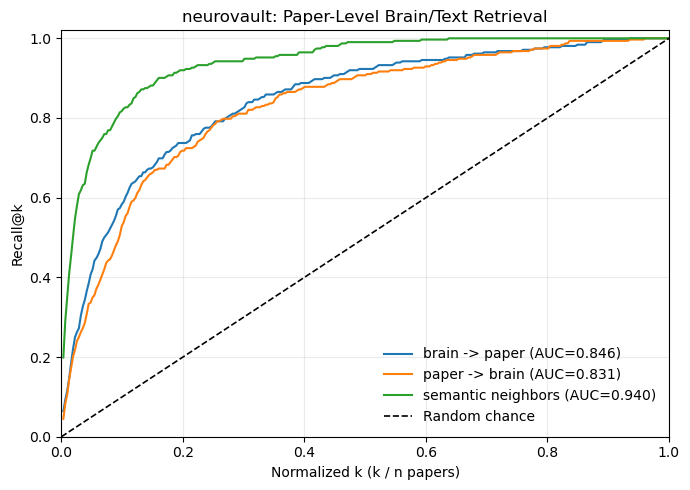

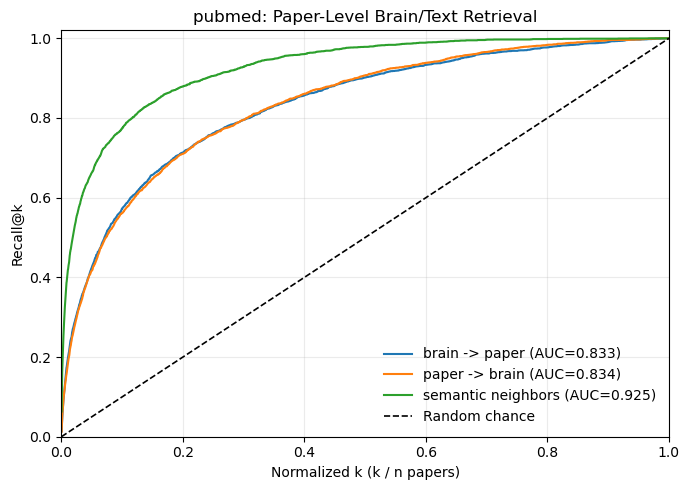

In [13]:
if len(b2t_paper_retrieval_curves_df):
    metric_labels = [
        ("brain_to_paper_recall_curve", "brain -> paper", "brain_to_paper_normalized_k_recall_curve_auc"),
        ("paper_to_brain_recall_curve", "paper -> brain", "paper_to_brain_normalized_k_recall_curve_auc"),
        ("semantic_recall_curve", "semantic neighbors", "semantic_normalized_k_recall_curve_auc"),
    ]
    for dataset, sub in b2t_paper_retrieval_curves_df.groupby("dataset"):
        metrics_row = b2t_paper_retrieval_metrics_df.set_index("dataset").loc[dataset]
        fig, ax = plt.subplots(figsize=(7, 5))
        for curve_col, label, auc_col in metric_labels:
            auc = float(metrics_row[auc_col])
            ax.plot(sub["normalized_k"], sub[curve_col], label=f"{label} (AUC={auc:.3f})")
        ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
        ax.set_xlabel("Normalized k (k / n papers)")
        ax.set_ylabel("Recall@k")
        ax.set_title(f"{dataset}: Paper-Level Brain/Text Retrieval")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
        fig.tight_layout()
        plt.savefig(OUTPUT_DIR / f"b2t_paper_retrieval_curves_{dataset}.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("No paper retrieval curves to plot.")


### Network Gold-Term Ranking

This evaluates whether the full ranked NeuroVLM term list retrieves known network terms from the network test-set CSV. The candidate corpus is intentionally broad (`llm_neuro_terms`, `kg_mesh`, and `cogatlas`), while the gold terms come from the CSV. A CSV-term-only candidate corpus should lead to the same interpretation when results are reported against normalized k; this broader corpus is the stricter retrieval setting.

Metric columns:

- `normalized_k_target`: the requested fraction of the candidate corpus to inspect, such as `0.01` for the top 1%.
- `k`: the actual number of retrieved terms inspected, computed as `ceil(normalized_k_target * n_candidate_terms)`.
- `n_candidate_terms`: the number of unique terms the model could rank after normalizing/deduplicating term names.
- `n_gold_terms`: gold terms that are reachable in the candidate corpus. Unreachable terms are excluded so the model is not penalized for terms it could never retrieve.
- `n_unreachable_gold_terms`: gold terms missing from the retrieval corpora; this is a fairness/audit check.
- `precision_at_normalized_k`: among the inspected top-k terms, the fraction that are gold terms.
- `recall_at_normalized_k`: among the reachable gold terms, the fraction recovered within the inspected top-k terms.
- `hit_at_normalized_k`: whether at least one gold term appears in the inspected top-k terms.
- `mrr_at_normalized_k`: reciprocal rank of the first gold-term hit if it appears within top-k.
- `normalized_first_hit_rank`: first gold-term rank divided by `n_candidate_terms`; lower is better and accounts for corpus size.
- `expected_random_recall_at_normalized_k`: chance-level recall if terms were randomly ordered.
- `recall_auc`: area under the recall-vs-normalized-k curve. Higher means gold terms appear earlier across the full ranked list.

The recall curve plots `recall_at_normalized_k` on the y-axis and normalized k on the x-axis. A curve above the diagonal means the brain-to-text retrieval ranks gold terms earlier than random chance.


In [14]:
def _k_from_normalized_k(normalized_k: float, n_candidates: int) -> int:
    if n_candidates <= 0 or normalized_k <= 0:
        return 0
    return min(n_candidates, max(1, int(np.ceil(float(normalized_k) * n_candidates))))


def _auc_trapezoid(x, y) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


def exact_term_ranking_outputs(
    dataset: str,
    sample: str,
    gold_terms: list[str],
    retrieved_terms: list[str],
    reachable_terms: set[str] | None = None,
):
    gold_norm_all = {normalize_term_text(t) for t in gold_terms if normalize_term_text(t)}
    if reachable_terms is None:
        gold_norm = gold_norm_all
        excluded = set()
    else:
        gold_norm = gold_norm_all & reachable_terms
        excluded = gold_norm_all - reachable_terms

    retrieved_norm = []
    seen = set()
    for term in retrieved_terms:
        norm = normalize_term_text(term)
        if norm and norm not in seen:
            retrieved_norm.append(norm)
            seen.add(norm)

    if not gold_norm or not retrieved_norm:
        return [], [], None

    n_candidates = len(retrieved_norm)
    first_hit_rank = next((i + 1 for i, term in enumerate(retrieved_norm) if term in gold_norm), np.nan)
    normalized_first_hit_rank = float(first_hit_rank / n_candidates) if not pd.isna(first_hit_rank) else np.nan

    metric_rows = []
    for normalized_k_target in TERM_EVAL_NORMALIZED_KS:
        k = _k_from_normalized_k(normalized_k_target, n_candidates)
        topk = retrieved_norm[:k]
        hits = set(topk) & gold_norm
        normalized_k = k / n_candidates if n_candidates else np.nan
        metric_rows.append({
            "dataset": dataset,
            "sample": sample,
            "normalized_k_target": float(normalized_k_target),
            "normalized_k": float(normalized_k),
            "k": int(k),
            "n_candidate_terms": int(n_candidates),
            "n_gold_terms": len(gold_norm),
            "n_unreachable_gold_terms": len(excluded),
            "n_retrieved_terms": len(topk),
            "n_hits": len(hits),
            "precision_at_normalized_k": len(hits) / max(len(topk), 1),
            "recall_at_normalized_k": len(hits) / len(gold_norm),
            "hit_at_normalized_k": bool(hits),
            "mrr_at_normalized_k": 0.0 if pd.isna(first_hit_rank) or first_hit_rank > k else 1.0 / float(first_hit_rank),
            "normalized_first_hit_rank": normalized_first_hit_rank,
            "expected_random_recall_at_normalized_k": float(normalized_k_target),
            "matched_terms": "; ".join(sorted(hits)),
        })

    curve_rows = []
    recall_values = []
    for normalized_k_target in TERM_RECALL_CURVE_NORMALIZED_KS:
        k = _k_from_normalized_k(normalized_k_target, n_candidates)
        topk = retrieved_norm[:k]
        hits = set(topk) & gold_norm
        recall = len(hits) / len(gold_norm)
        recall_values.append(recall)
        curve_rows.append({
            "dataset": dataset,
            "sample": sample,
            "normalized_k_target": float(normalized_k_target),
            "normalized_k": float(k / n_candidates) if n_candidates else np.nan,
            "k": int(k),
            "n_candidate_terms": int(n_candidates),
            "n_gold_terms": len(gold_norm),
            "recall_at_normalized_k": float(recall),
            "expected_random_recall_at_normalized_k": float(normalized_k_target),
        })

    auc = _auc_trapezoid(TERM_RECALL_CURVE_NORMALIZED_KS, recall_values)
    auc_row = {
        "dataset": dataset,
        "sample": sample,
        "n_candidate_terms": int(n_candidates),
        "n_gold_terms": len(gold_norm),
        "n_unreachable_gold_terms": len(excluded),
        "recall_auc": float(auc),
        "expected_random_recall_auc": 0.5,
        "recall_auc_minus_random": float(auc - 0.5),
        "normalized_first_hit_rank": normalized_first_hit_rank,
    }
    return metric_rows, curve_rows, auc_row


network_candidate_terms = set().union(*(terms_for_dataset(ds) for ds in NETWORK_B2T_TERM_DATASETS))
network_missing_rows = []
for sample_name in networks_data:
    for term in network_gold_terms(sample_name):
        norm = normalize_term_text(term)
        if norm and norm not in network_candidate_terms:
            network_missing_rows.append({"sample": sample_name, "term": term, "normalized_term": norm})
network_missing_terms_df = pd.DataFrame(network_missing_rows).drop_duplicates() if network_missing_rows else pd.DataFrame(columns=["sample", "term", "normalized_term"])
display(network_missing_terms_df.head(25))
print(f"Network gold terms missing from llm_neuro_terms + kg_mesh + cogatlas: {len(network_missing_terms_df):,}")
if len(network_missing_terms_df):
    network_missing_terms_df.to_csv(OUTPUT_DIR / "network_gold_terms_missing_from_retrieval_corpora.csv", index=False)

pubmed_candidate_terms = terms_for_dataset(PUBMED_B2T_DATASET)


,sample,term,normalized_term


Network gold terms missing from llm_neuro_terms + kg_mesh + cogatlas: 0


In [15]:
term_metric_rows = []
term_curve_rows = []
term_auc_rows = []
term_examples = []

for dataset, sample, latent, gold_terms, _references in tqdm(list(dataset_records_for_retrieval_eval()), desc="Network normalized gold-term ranking"):
    if dataset != "networks":
        continue
    table = full_retrieval_table_for_sample(latent, dataset, sample)
    retrieved_terms = unique_ranked_terms_from_table(table)
    reachable_terms = network_candidate_terms
    metric_rows, curve_rows, auc_row = exact_term_ranking_outputs(dataset, sample, gold_terms, retrieved_terms, reachable_terms=reachable_terms)
    term_metric_rows.extend(metric_rows)
    term_curve_rows.extend(curve_rows)
    if auc_row is not None:
        term_auc_rows.append(auc_row)
    term_examples.append({
        "dataset": dataset,
        "sample": sample,
        "gold_terms": "; ".join(gold_terms[:50]),
        "n_ranked_candidate_terms": len(retrieved_terms),
        "top_terms": "; ".join(retrieved_terms[:B2T_TERM_EXAMPLE_TOP_K]),
    })

b2t_term_metrics_df = pd.DataFrame(term_metric_rows)
b2t_term_recall_curve_df = pd.DataFrame(term_curve_rows)
b2t_term_auc_df = pd.DataFrame(term_auc_rows)
b2t_term_examples_df = pd.DataFrame(term_examples)

b2t_term_metrics_df.to_csv(OUTPUT_DIR / "b2t_approach1_gold_term_ranking_metrics.csv", index=False)
b2t_term_recall_curve_df.to_csv(OUTPUT_DIR / "b2t_approach1_gold_term_recall_curve.csv", index=False)
b2t_term_auc_df.to_csv(OUTPUT_DIR / "b2t_approach1_gold_term_recall_auc.csv", index=False)
b2t_term_examples_df.to_csv(OUTPUT_DIR / "b2t_approach1_gold_term_examples.csv", index=False)

if len(b2t_term_metrics_df):
    display(
        b2t_term_metrics_df
        .groupby(["dataset", "normalized_k_target"])[
            [
                "normalized_k", "k", "n_candidate_terms",
                "precision_at_normalized_k", "recall_at_normalized_k",
                "hit_at_normalized_k", "mrr_at_normalized_k",
                "expected_random_recall_at_normalized_k", "n_unreachable_gold_terms",
            ]
        ]
        .mean()
        .round(3)
    )
    display(b2t_term_auc_df.groupby("dataset")[["recall_auc", "expected_random_recall_auc", "recall_auc_minus_random"]].agg(["mean", "std", "count"]).round(3))
else:
    print("No network gold-term metrics were computed.")


Network normalized gold-term ranking:   0%|          | 0/3418 [00:00<?, ?it/s]

normalized_k       k  n_candidate_terms  \
dataset  normalized_k_target                                            
networks 0.001                       0.001    36.0            35896.0   
         0.005                       0.005   180.0            35896.0   
         0.010                       0.010   359.0            35896.0   
         0.020                       0.020   718.0            35896.0   
         0.050                       0.050  1795.0            35896.0   
         0.100                       0.100  3590.0            35896.0   

                              precision_at_normalized_k  \
dataset  normalized_k_target                              
networks 0.001                                    0.110   
         0.005                                    0.049   
         0.010                                    0.031   
         0.020                                    0.018   
         0.050                                    0.008   
         0.100                                    0.004   

                              recall_at_normalized_k  hit_at_normalized_k  \
dataset  normalized_k_target                                                
networks 0.001                                 0.177                0.798   
         0.005                                 0.401                0.908   
         0.010                                 0.513                0.950   
         0.020                                 0.606                0.983   
         0.050                                 0.697                1.000   
         0.100                                 0.747                1.000   

                              mrr_at_normalized_k  \
dataset  normalized_k_target                        
networks 0.001                              0.236   
         0.005                              0.238   
         0.010                              0.238   
         0.020                              0.238   
         0.050                              0.238   
         0.100                              0.238   

                              expected_random_recall_at_normalized_k  \
dataset  normalized_k_target                                           
networks 0.001                                                 0.001   
         0.005                                                 0.005   
         0.010                                                 0.010   
         0.020                                                 0.020   
         0.050                                                 0.050   
         0.100                                                 0.100   

                              n_unreachable_gold_terms  
dataset  normalized_k_target                            
networks 0.001                                     0.0  
         0.005                                     0.0  
         0.010                                     0.0  
         0.020                                     0.0  
         0.050                                     0.0  
         0.100                                     0.0

recall_auc              expected_random_recall_auc             \
               mean    std count                       mean  std count   
dataset                                                                  
networks      0.837  0.159   119                        0.5  0.0   119   

         recall_auc_minus_random               
                            mean    std count  
dataset                                        
networks                   0.337  0.159   119

### Network Term-Ranking Visualization

This plot shows how quickly known network gold terms appear as the normalized term budget grows. Because the x-axis is `k / n_candidate_terms`, the curve remains interpretable even when comparing the broad NeuroVLM corpus with a smaller CSV-term-only corpus.


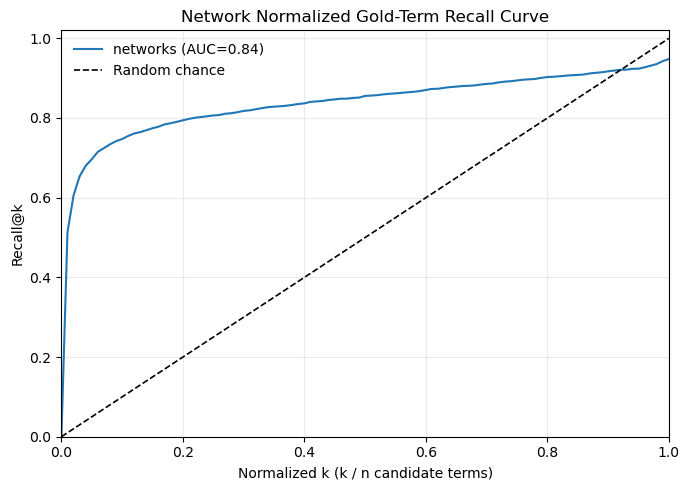

In [16]:
if len(b2t_term_recall_curve_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    curve_summary = (
        b2t_term_recall_curve_df
        .groupby(["dataset", "normalized_k_target"])
        .agg(recall_mean=("recall_at_normalized_k", "mean"), recall_std=("recall_at_normalized_k", "std"), n=("sample", "count"))
        .reset_index()
    )
    auc_means = b2t_term_auc_df.groupby("dataset")["recall_auc"].mean().to_dict()
    for dataset, sub in curve_summary.groupby("dataset"):
        label = f"{dataset} (AUC={auc_means.get(dataset, np.nan):.2f})"
        ax.plot(sub["normalized_k_target"], sub["recall_mean"], label=label)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n candidate terms)")
    ax.set_ylabel("Recall@k")
    ax.set_title("Network Normalized Gold-Term Recall Curve")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_approach1_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No recall curve rows to plot.")


In [17]:
if RUN_GENERATED_TEXT:
    # Pre-download Hugging Face assets used by BERTScore so metric calls do not
    # repeatedly block on tokenizer/model metadata requests during the eval loop.
    def predownload_hf_model(model_name: str):
        print(f"Pre-downloading Hugging Face model for BERTScore: {model_name}")
        AutoTokenizer.from_pretrained(model_name, use_fast=False)
        AutoModel.from_pretrained(model_name)
        print("BERTScore model is cached.")

    predownload_hf_model(BERTSCORE_MODEL)
else:
    print("Skipping BERTScore model pre-download because RUN_GENERATED_TEXT = False.")


Skipping BERTScore model pre-download because RUN_GENERATED_TEXT = False.


### PubMed MeSH Gold-Term Ranking

This is a term-recovery diagnostic for PubMed, separate from the primary paper-level retrieval metric. It uses the same multi-positive ranking definition as `evaluate_mesh_term_ranking`: for each paper, any allowed gold MeSH term can be the first positive hit, and the recall-curve AUC is computed from the best true-term rank over the full candidate list.

Both the candidate corpus and the ground-truth MeSH terms are restricted to the brain-rankable MeSH node types: `disorder`, `anatomical_region`, `biological_process`, and `cognitive_construct` by default. This should line up with `mesh_paper_recall_curve_auc` / `mesh_normalized_k_recall_curve_auc` from the semantic baseline run.


In [18]:
from neurovlm.semantic_evaluation import multi_positive_ranking_metrics


def load_pubmed_mesh_gold_annotations_or_none():
    try:
        annotations = load_dataset("pubmed_mesh_annotations")
        print(f"Loaded PubMed MeSH annotations for {len(annotations):,} PMIDs")
        return annotations
    except Exception as e:
        print("PubMed MeSH gold annotations are unavailable; skipping MeSH term-ranking diagnostics.")
        print(f"Loader error: {type(e).__name__}: {e}")
        return None


def mesh_descriptor_name(term: str) -> str:
    return str(term).split("/")[0].strip()


PUBMED_MESH_GOLD_ANNOTATIONS = load_pubmed_mesh_gold_annotations_or_none()
PUBMED_MESH_NODE_TYPE_BY_TERM = {}
if PUBMED_MESH_GOLD_ANNOTATIONS is not None:
    try:
        mesh_nodes_for_gold = load_dataset("mesh_kg_nodes")
        if "node_type" in mesh_nodes_for_gold.columns:
            name_col = "name" if "name" in mesh_nodes_for_gold.columns else "term"
            PUBMED_MESH_NODE_TYPE_BY_TERM = {
                normalize_term_text(row[name_col]): row["node_type"]
                for _, row in mesh_nodes_for_gold.iterrows()
                if pd.notna(row.get(name_col)) and pd.notna(row.get("node_type"))
            }
    except Exception as e:
        print(f"Could not load mesh_kg_nodes for node-type filtering: {type(e).__name__}: {e}")


allowed_mesh_types = set(MESH_BRAIN_RANKABLE_NODE_TYPES)
mesh_candidate_df = load_dataset(PUBMED_B2T_DATASET).copy()
mesh_candidate_latents, mesh_candidate_terms = load_latent(PUBMED_B2T_DATASET)
mesh_candidate_terms = np.asarray(mesh_candidate_terms).astype(str)

if len(mesh_candidate_df) != len(mesh_candidate_latents):
    raise ValueError(
        f"MeSH candidate metadata/latent length mismatch: metadata={len(mesh_candidate_df)} latents={len(mesh_candidate_latents)}"
    )

mesh_term_col = next((col for col in ["term", "title", "name", "label"] if col in mesh_candidate_df.columns), None)
if mesh_term_col is None:
    raise KeyError(f"{PUBMED_B2T_DATASET} must contain one of term/title/name/label columns.")
mesh_candidate_df["term"] = mesh_candidate_df[mesh_term_col].astype(str).map(mesh_descriptor_name)
mesh_candidate_df["normalized_term"] = mesh_candidate_df["term"].map(normalize_term_text)
mesh_candidate_df["node_type"] = mesh_candidate_df["normalized_term"].map(PUBMED_MESH_NODE_TYPE_BY_TERM).fillna("")

if PUBMED_MESH_NODE_TYPE_BY_TERM:
    keep_mask = mesh_candidate_df["node_type"].isin(allowed_mesh_types).to_numpy()
    mesh_candidate_df = mesh_candidate_df.loc[keep_mask].reset_index(drop=True)
    mesh_candidate_latents = mesh_candidate_latents[keep_mask]

mesh_candidate_df = mesh_candidate_df.drop_duplicates("normalized_term", keep="first").reset_index(drop=True)
# Keep latents aligned after duplicate removal.
mesh_keep_indices = mesh_candidate_df.index.to_numpy()
# If duplicate removal reset the index, rebuild from original unique positions instead.
# Pandas retained row order before reset, so use duplicated mask from the filtered frame.
_filtered_terms = load_dataset(PUBMED_B2T_DATASET).copy()
_filtered_terms["term"] = _filtered_terms[mesh_term_col].astype(str).map(mesh_descriptor_name)
_filtered_terms["normalized_term"] = _filtered_terms["term"].map(normalize_term_text)
_filtered_terms["node_type"] = _filtered_terms["normalized_term"].map(PUBMED_MESH_NODE_TYPE_BY_TERM).fillna("")
_filtered_mask = _filtered_terms["node_type"].isin(allowed_mesh_types).to_numpy() if PUBMED_MESH_NODE_TYPE_BY_TERM else np.ones(len(_filtered_terms), dtype=bool)
_unique_mask = _filtered_terms.loc[_filtered_mask, "normalized_term"].duplicated(keep="first").to_numpy() == False
mesh_candidate_latents = mesh_candidate_latents[_unique_mask]

mesh_candidate_embeddings = _project_text_latents_to_shared(mesh_candidate_latents)
mesh_candidate_terms = mesh_candidate_df["term"].astype(str).tolist()
mesh_norm_to_idx = {norm: i for i, norm in enumerate(mesh_candidate_df["normalized_term"].astype(str))}
mesh_candidate_norms = set(mesh_norm_to_idx)


def pubmed_mesh_gold_terms(pmid) -> list[str]:
    if PUBMED_MESH_GOLD_ANNOTATIONS is None:
        return []
    out = []
    for term in PUBMED_MESH_GOLD_ANNOTATIONS.get(str(pmid), []):
        base = mesh_descriptor_name(term)
        norm = normalize_term_text(base)
        if not norm or norm not in mesh_candidate_norms:
            continue
        if PUBMED_MESH_NODE_TYPE_BY_TERM and PUBMED_MESH_NODE_TYPE_BY_TERM.get(norm) not in allowed_mesh_types:
            continue
        out.append(base)
    return list(dict.fromkeys(out))


mesh_records = []
mesh_true_indices = []
mesh_true_terms = []
if RUN_PUBMED and PUBMED_MESH_GOLD_ANNOTATIONS is not None:
    for d in pubmed_eval:
        pmid = str(d["pmid"])
        positives = []
        terms = []
        for term in pubmed_mesh_gold_terms(pmid):
            idx = mesh_norm_to_idx.get(normalize_term_text(term))
            if idx is not None:
                positives.append(idx)
                terms.append(mesh_candidate_terms[idx])
        if not positives:
            continue
        mesh_records.append(d)
        mesh_true_indices.append(set(positives))
        mesh_true_terms.append(sorted(set(terms)))

if mesh_records:
    mesh_brain_embeddings = _project_brain_latents_to_shared([d["latent"] for d in mesh_records])
    mesh_scores = (mesh_brain_embeddings @ mesh_candidate_embeddings.T).detach().cpu().numpy()
    mesh_metrics = multi_positive_ranking_metrics(mesh_scores, mesh_true_indices, ks=(1, 5, 10, 50), ndcg_k=10)
    mesh_order = np.argsort(-mesh_scores, axis=1)

    b2t_mesh_term_metrics_df = pd.DataFrame([
        {
            "dataset": "pubmed_mesh",
            "n_queries": mesh_metrics["n_queries"],
            "n_candidates": mesh_metrics["n_candidates"],
            "mesh_paper_recall_curve_auc": mesh_metrics["paper_recall_curve_auc"],
            "mesh_normalized_k_recall_curve_auc": mesh_metrics["normalized_k_recall_curve_auc"],
            "mesh_recall@1": mesh_metrics["recall@1"],
            "mesh_recall@5": mesh_metrics["recall@5"],
            "mesh_recall@10": mesh_metrics["recall@10"],
            "mesh_recall@50": mesh_metrics["recall@50"],
            "mesh_map": mesh_metrics["map"],
            "mesh_mrr": mesh_metrics["mrr"],
            "mesh_ndcg@10": mesh_metrics["ndcg@10"],
            "mesh_median_best_true_term_rank": mesh_metrics["median_best_true_term_rank"],
            "allowed_node_types": ";".join(MESH_BRAIN_RANKABLE_NODE_TYPES),
        }
    ])

    counts = np.zeros(len(mesh_candidate_terms), dtype=np.int64)
    for i, positives in enumerate(mesh_true_indices):
        ranks_by_candidate = np.empty(len(mesh_candidate_terms), dtype=np.int64)
        ranks_by_candidate[mesh_order[i]] = np.arange(1, len(mesh_candidate_terms) + 1)
        best_rank = min(int(ranks_by_candidate[j]) for j in positives)
        counts[best_rank - 1] += 1
    recall_curve = np.cumsum(counts) / float(len(mesh_true_indices))
    b2t_mesh_term_recall_curve_df = pd.DataFrame({
        "dataset": "pubmed_mesh",
        "k": np.arange(1, len(mesh_candidate_terms) + 1),
        "normalized_k": normalized_k_values(len(mesh_candidate_terms)).cpu().numpy(),
        "recall_at_normalized_k": recall_curve,
        "expected_random_recall_at_normalized_k": normalized_k_values(len(mesh_candidate_terms)).cpu().numpy(),
    })

    example_rows = []
    for i, d in enumerate(mesh_records):
        positives = mesh_true_indices[i]
        ranks_by_candidate = np.empty(len(mesh_candidate_terms), dtype=np.int64)
        ranks_by_candidate[mesh_order[i]] = np.arange(1, len(mesh_candidate_terms) + 1)
        top = mesh_order[i, :B2T_TERM_EXAMPLE_TOP_K]
        example_rows.append({
            "dataset": "pubmed_mesh",
            "sample": str(d["pmid"]),
            "true_mesh_terms": "; ".join(mesh_true_terms[i]),
            "best_true_term_rank": min(int(ranks_by_candidate[j]) for j in positives),
            "top_terms": "; ".join(mesh_candidate_terms[j] for j in top),
            "top_scores": "; ".join(f"{mesh_scores[i, j]:.6f}" for j in top),
            "hit@5": bool(any(j in positives for j in mesh_order[i, :5])),
            "hit@10": bool(any(j in positives for j in mesh_order[i, :10])),
        })
    b2t_mesh_term_examples_df = pd.DataFrame(example_rows)
else:
    mesh_metrics = {}
    b2t_mesh_term_metrics_df = pd.DataFrame()
    b2t_mesh_term_recall_curve_df = pd.DataFrame()
    b2t_mesh_term_examples_df = pd.DataFrame()

b2t_mesh_term_metrics_df.to_csv(OUTPUT_DIR / "b2t_pubmed_mesh_gold_term_ranking_metrics.csv", index=False)
b2t_mesh_term_metrics_df.to_json(OUTPUT_DIR / "b2t_pubmed_mesh_gold_term_ranking_metrics.json", orient="records", indent=2)
b2t_mesh_term_recall_curve_df.to_csv(OUTPUT_DIR / "b2t_pubmed_mesh_gold_term_recall_curve.csv", index=False)
b2t_mesh_term_recall_curve_df.to_json(OUTPUT_DIR / "b2t_pubmed_mesh_gold_term_recall_curve.json", orient="records", indent=2)
b2t_mesh_term_examples_df.to_csv(OUTPUT_DIR / "b2t_pubmed_mesh_gold_term_examples.csv", index=False)
b2t_mesh_term_examples_df.to_json(OUTPUT_DIR / "b2t_pubmed_mesh_gold_term_examples.json", orient="records", indent=2)

if len(b2t_mesh_term_metrics_df):
    display(b2t_mesh_term_metrics_df.round(3))
else:
    print("No PubMed MeSH gold-term metrics were computed.")


Loaded PubMed MeSH annotations for 1,231,613 PMIDs


,dataset,n_queries,n_candidates,mesh_paper_recall_curve_auc,mesh_normalized_k_recall_curve_auc,mesh_recall@1,mesh_recall@5,mesh_recall@10,mesh_recall@50,mesh_map,mesh_mrr,mesh_ndcg@10,mesh_median_best_true_term_rank,allowed_node_types
0,pubmed_mesh,2450,9937,0.902,0.902,0.037,0.118,0.172,0.367,0.023,0.083,0.034,145.0,disorder;anatomical_region;biological_process;...


### PubMed MeSH Gold-Term Visualization

This plot shows MeSH gold-term recall as the normalized MeSH candidate budget grows. It is useful as a term-level diagnostic, while the paper-level retrieval plots remain the primary PubMed paper evaluation.


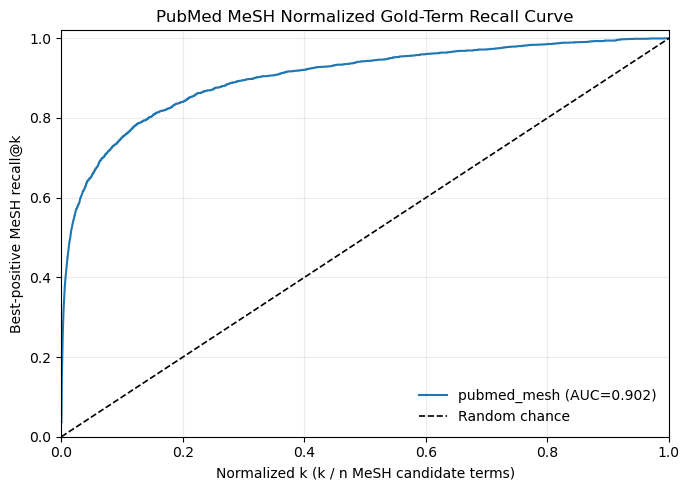

In [19]:
if len(b2t_mesh_term_recall_curve_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    auc = float(b2t_mesh_term_metrics_df.loc[0, "mesh_normalized_k_recall_curve_auc"])
    ax.plot(
        b2t_mesh_term_recall_curve_df["normalized_k"],
        b2t_mesh_term_recall_curve_df["recall_at_normalized_k"],
        label=f"pubmed_mesh (AUC={auc:.3f})",
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n MeSH candidate terms)")
    ax.set_ylabel("Best-positive MeSH recall@k")
    ax.set_title("PubMed MeSH Normalized Gold-Term Recall Curve")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_pubmed_mesh_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No PubMed MeSH recall curve rows to plot.")


## Generated Text Evaluation

This optional section compares LLM-generated text against the ground-truth text. It is disabled by default with `RUN_GENERATED_TEXT = False` because it is much slower than the retrieval metrics.

Metrics in this section, when enabled:

- `bert_p`, `bert_r`, `bert_f1`: BERTScore precision, recall, and F1 between generated text and ground truth. These check token-level contextual semantic overlap.
- `sem_sim`: MiniLM sentence-embedding similarity between generated text and ground truth.
- `nvlm_sim`: cosine similarity between the generated text embedding and the brain query in NeuroVLM's shared latent space.
- `generated_text_normalized_k_recall_curve_auc`: embeds each generated text and asks how early it retrieves its source brain map within the dataset/mode group, summarized as area under Recall@k over normalized `k / n`.
- Network label accuracy metrics: for Networks, these check whether the generated text names the correct network label by alias matching or semantic matching.

Because generation depends on the LLM as well as the retrieval results, this section should be interpreted alongside the paper-level retrieval and network term-ranking metrics.


In [20]:
if RUN_GENERATED_TEXT:
    b2t_frames = []

    if RUN_NETWORKS:
        records = []
        for net_name, d in tqdm(networks_data.items(), desc="Networks B2T"):
            records.extend(run_b2t(net_name, d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
        b2t_net_df = add_network_label_accuracy(pd.DataFrame(records))
        b2t_net_df["dataset"] = "networks"
        b2t_frames.append(b2t_net_df)

    if RUN_PUBMED:
        records = []
        for d in tqdm(pubmed_eval, desc="PubMed B2T"):
            records.extend(run_b2t(str(d["pmid"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_PUBMED, LONG_PROMPT, datasets=[PUBMED_B2T_DATASET]))
        b2t_pubmed_df = pd.DataFrame(records)
        b2t_pubmed_df["dataset"] = "pubmed"
        b2t_frames.append(b2t_pubmed_df)

    if RUN_NEUROVAULT:
        records = []
        for d in tqdm(neurovault_eval, desc="NeuroVault B2T"):
            records.extend(run_b2t(str(d["doi"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
        b2t_nv_df = pd.DataFrame(records)
        b2t_nv_df["dataset"] = "neurovault"
        b2t_frames.append(b2t_nv_df)

    b2t_all = pd.concat(b2t_frames, ignore_index=True)
    b2t_all.to_csv(OUTPUT_DIR / "brain_to_text_metrics_v2.csv", index=False)
    b2t_all.head()
else:
    print("Skipping generated text evaluation because RUN_GENERATED_TEXT = False.")
    b2t_all = pd.DataFrame()


Skipping generated text evaluation because RUN_GENERATED_TEXT = False.


### Generated Text Summary Tables

These tables summarize optional LLM-generation metrics. `bert_f1` measures contextual text overlap with the reference, `sem_sim` measures MiniLM sentence similarity, `nvlm_sim` measures similarity in NeuroVLM's shared latent space, and `generated_text_normalized_k_recall_curve_auc` measures whether generated texts retrieve their source brain maps early across the full normalized `k / n` retrieval curve within each dataset/mode group.


In [ ]:
if RUN_GENERATED_TEXT and len(b2t_all):
    def generated_text_retrieval_curve(df: pd.DataFrame):
        if len(df) < 2:
            return np.nan, pd.DataFrame()
        generated = df["generated"].astype(str).tolist()
        with torch.no_grad():
            raw = nvlm._encode_text(generated)
            z_text = nvlm._proj_head_text_infonce(raw.to(nvlm.device))
            z_text = F.normalize(z_text, dim=-1).cpu()
        brain_embs = []
        for _, row in df.iterrows():
            source = row["dataset"]
            name = row["name"]
            if source == "networks":
                brain_embs.append(networks_data[name]["latent"])
            elif source == "pubmed":
                brain_embs.append(next(d["latent"] for d in pubmed_eval if str(d["pmid"]) == str(name)))
            elif source == "neurovault":
                brain_embs.append(next(d["latent"] for d in neurovault_eval if str(d["doi"]) == str(name)))
        z_brain = _project_brain_latents_to_shared(brain_embs)
        scores = z_text @ z_brain.T
        order = scores.argsort(dim=1, descending=True)
        target = torch.arange(len(df)).view(-1, 1)
        first_hits = order.eq(target).int().argmax(dim=1)
        hit_counts = torch.bincount(first_hits.cpu(), minlength=len(df)).float()
        recall_curve = torch.cumsum(hit_counts, dim=0) / float(len(df))
        normalized_k = normalized_k_values(len(df)).cpu().numpy()
        auc = normalized_recall_curve_auc(recall_curve)
        curve_df = pd.DataFrame({
            "k": np.arange(1, len(df) + 1),
            "normalized_k": normalized_k,
            "recall_at_normalized_k": recall_curve.cpu().numpy(),
            "expected_random_recall_at_normalized_k": normalized_k,
        })
        return auc, curve_df

    generated_text_recall_rows = []
    generated_text_curve_rows = []
    for (dataset, mode), sub in b2t_all.groupby(["dataset", "mode"]):
        sub = sub.reset_index(drop=True)
        auc, curve_df = generated_text_retrieval_curve(sub)
        generated_text_recall_rows.append({
            "dataset": dataset,
            "mode": mode,
            "generated_text_normalized_k_recall_curve_auc": auc,
            "n": len(sub),
        })
        if len(curve_df):
            curve_df.insert(0, "mode", mode)
            curve_df.insert(0, "dataset", dataset)
            generated_text_curve_rows.append(curve_df)

    generated_text_recall_auc_df = pd.DataFrame(generated_text_recall_rows)
    generated_text_recall_curve_df = pd.concat(generated_text_curve_rows, ignore_index=True) if generated_text_curve_rows else pd.DataFrame()
    summary = b2t_all.groupby(["dataset", "mode"])[["nvlm_sim", "bert_f1", "sem_sim"]].agg(["mean", "std", "count"]).round(3)
    summary.to_csv(OUTPUT_DIR / "b2t_generated_text_metric_summary.csv")
    summary.reset_index().to_json(OUTPUT_DIR / "b2t_generated_text_metric_summary.json", orient="records", indent=2)
    generated_text_recall_auc_df.round(3).to_csv(OUTPUT_DIR / "b2t_generated_text_recall_auc.csv", index=False)
    generated_text_recall_auc_df.round(3).to_json(OUTPUT_DIR / "b2t_generated_text_recall_auc.json", orient="records", indent=2)
    if len(generated_text_recall_curve_df):
        generated_text_recall_curve_df.to_csv(OUTPUT_DIR / "b2t_generated_text_recall_curve.csv", index=False)
        generated_text_recall_curve_df.to_json(OUTPUT_DIR / "b2t_generated_text_recall_curve.json", orient="records", indent=2)
    display(summary)
    display(generated_text_recall_auc_df.round(3))

    if "network_label_correct" in b2t_all.columns:
        label_summary = b2t_all[b2t_all["dataset"] == "networks"].groupby("mode")["network_label_correct"].agg(["mean", "sum", "count"]).round(3)
        label_summary.to_csv(OUTPUT_DIR / "b2t_generated_text_network_label_accuracy_summary.csv")
        label_summary.reset_index().to_json(OUTPUT_DIR / "b2t_generated_text_network_label_accuracy_summary.json", orient="records", indent=2)
        display(label_summary)
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


### Generated Text Normalized Recall Curves

This plot shows the full generated-text retrieval curve. Each generated output is embedded back into the NeuroVLM text space and ranked against the brain maps in the same dataset/mode group; the AUC summarizes Recall@k over normalized `k / n`, so groups with different sizes are comparable.


In [ ]:
if RUN_GENERATED_TEXT and len(b2t_all) and len(generated_text_recall_curve_df):
    fig, ax = plt.subplots(figsize=(8, 5))
    for (dataset, mode), curve_df in generated_text_recall_curve_df.groupby(["dataset", "mode"]):
        auc_row = generated_text_recall_auc_df[
            (generated_text_recall_auc_df["dataset"] == dataset) &
            (generated_text_recall_auc_df["mode"] == mode)
        ]
        auc = float(auc_row["generated_text_normalized_k_recall_curve_auc"].iloc[0]) if len(auc_row) else np.nan
        ax.plot(
            curve_df["normalized_k"],
            curve_df["recall_at_normalized_k"],
            label=f"{dataset} {mode} (AUC={auc:.3f})",
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_xlabel("Normalized k (k / n brain maps)")
    ax.set_ylabel("Generated-text recall@k")
    ax.set_title("Generated Text Normalized Brain Retrieval Curves")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_generated_text_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping generated-text normalized recall curve because RUN_GENERATED_TEXT = False or no curve rows are available.")


In [22]:
if RUN_GENERATED_TEXT and len(b2t_all):
    b2t_all[(b2t_all["mode"] == "short") & (b2t_all["dataset"] == "pubmed")].iloc[0].get("generated")
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


In [23]:
if RUN_GENERATED_TEXT and len(b2t_all):
    '''
    '[kg_mesh] sim=0.534 | surgical equipment\n
     [kg_mesh] sim=0.529 | acetylene\n
     [kg_mesh] sim=0.522 | equipment and supplies, hospital\n
     [kg_mesh] sim=0.522 | hospitals, packaged\n
     [kg_mesh] sim=0.519 | cellular neural networks, computer'
    '''
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


In [24]:
if RUN_GENERATED_TEXT and len(b2t_all):
    ''''
    Acoustic neuromas, benign tumors of the auditory nerve, exhibit correlations between their morphology and 
    otoneurological manifestations. The size and site of origin of these tumors influence clinical presentation,
     with patients having lateral neuromas typically experiencing early subjective hearing loss due to smaller 
     tumors often confined to the internal auditory canal. In contrast, medial neuromas tend to be larger and 
     may grow without causing significant audiological symptoms, often preserving normal hearing function. 
     The sensitivity of the stapedial reflex test is higher for lateral neuromas, while vestibular tests 
     indicate a higher frequency of central vestibular involvement in larger tumors. The combination of 
     brainstem auditory evoked potentials and vestibular tests can effectively identify acoustic neuromas,
       offering an optimal level of sensitivity.'


    '''
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


In [25]:
if RUN_GENERATED_TEXT and len(b2t_all):
    '''
    'Surgical Equipment encompasses a range of instruments and tools essential for medical interventions, including those related to Magnetic Resonance Imaging (MRI). 
    Acetylene, though not directly involved in biological processes, plays a role in MRI by being used in the cooling systems of some MRI machines. 
    Equipment and Supplies, Hospital, refers to the diverse set of medical devices and consumables utilized in hospitals for various diagnostic procedures, 
    which can include MRI and other imaging techniques. Hospitals, Packaged, denotes pre-assembled medical equipment and supplies designed for efficient use in 
    clinical settings, often including items that support MRI and ultrasonography. These components collectively ensure the smooth operation and precision of surgical 
    and diagnostic procedures, highlighting the integral role of specialized tools and technology in modern medical practice.'
    '''
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


In [26]:
if RUN_GENERATED_TEXT and len(b2t_all):
    '''
    "Neuroimaging Evidence of Surgical Equipment Usage in MRI Procedures\n\nSurgical equipment and supplies used in hospitals are crucial for various medical 
    interventions, including those related to Magnetic Resonance Imaging (MRI). Acetylene, though not a direct component of brain activity during MRI, plays 
    a role in the technology's operation. Hospitals often package these surgical tools and supplies together, facilitating efficient use in diagnostic procedures. 
    The underlying neural network supporting such tasks might involve cellular neural networks, which model biological neurons to recognize patterns and process signals,
    reflecting the complex integration of medical equipment with brain functions during imaging procedures."
    '''
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


In [27]:
if RUN_GENERATED_TEXT and len(b2t_all):
    "'Acoustic neuroma: correlations between morphology and otoneurological manifestations.'"
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


### Generated Text Metric Distributions

These plots show the distribution of generated-text scores by dataset and output mode, making it easier to see whether an average is driven by consistent behavior or a few strong/weak examples.


In [28]:
if RUN_GENERATED_TEXT and len(b2t_all):
    plot_df = b2t_all.copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metric_specs = [("nvlm_sim", "NeuroVLM latent similarity"), ("bert_f1", "BERTScore F1"), ("sem_sim", "Sentence semantic similarity")]
    for ax, (metric, title) in zip(axes, metric_specs):
        groups = [g[metric].dropna().values for _, g in plot_df.groupby("dataset")]
        labels = [k for k, _ in plot_df.groupby("dataset")]
        ax.boxplot(groups, labels=labels, showmeans=True)
        ax.set_title(title)
        ax.set_ylim(min(-0.05, np.nanmin(plot_df[metric]) - 0.05), min(1.05, np.nanmax(plot_df[metric]) + 0.1))
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=15)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_metric_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


### NeuroVLM Similarity Scale Check

This visualization compares matched generated-text/brain similarities with random pairings. It gives `nvlm_sim` an empirical baseline, which is more useful than reading cosine similarity as if only values near 1.0 were meaningful.


In [29]:
if RUN_GENERATED_TEXT and len(b2t_all):
    def _brain_latents_for_group(df):
        brain_embs = []
        for _, row in df.iterrows():
            source = row["dataset"]
            name = row["name"]
            if source == "networks":
                brain_embs.append(networks_data[name]["latent"])
            elif source == "pubmed":
                brain_embs.append(next(d["latent"] for d in pubmed_eval if str(d["pmid"]) == str(name)))
            elif source == "neurovault":
                brain_embs.append(next(d["latent"] for d in neurovault_eval if str(d["doi"]) == str(name)))
        return F.normalize(torch.stack([b.cpu() for b in brain_embs]), dim=-1)


    def _text_latents_for_group(df):
        nvlm._ensure_projection_heads()
        generated = df["generated"].astype(str).tolist()
        with torch.no_grad():
            raw = nvlm._encode_text(generated)
            z_text = nvlm._proj_head_text_infonce(raw.to(nvlm.device))
            return F.normalize(z_text, dim=-1).cpu()

    baseline_rows = []
    for (dataset, mode), sub in b2t_all.groupby(["dataset", "mode"]):
        if len(sub) < 2:
            continue
        sub = sub.reset_index(drop=True)
        z_text = _text_latents_for_group(sub)
        z_brain = _brain_latents_for_group(sub)
        scores = z_text @ z_brain.T
        eye = torch.eye(len(sub), dtype=torch.bool)
        for val in scores[eye].numpy():
            baseline_rows.append({"dataset": dataset, "mode": mode, "pair": "matched", "score": float(val)})
        for val in scores[~eye].numpy():
            baseline_rows.append({"dataset": dataset, "mode": mode, "pair": "random/off-diagonal", "score": float(val)})

    baseline_df = pd.DataFrame(baseline_rows)
    fig, ax = plt.subplots(figsize=(8, 4))
    if len(baseline_df):
        matched = baseline_df[baseline_df["pair"] == "matched"]["score"]
        random_pairs = baseline_df[baseline_df["pair"] == "random/off-diagonal"]["score"]
        bins = np.linspace(min(baseline_df["score"].min(), 0), baseline_df["score"].max(), 24)
        ax.hist(random_pairs, bins=bins, alpha=0.55, label="random/off-diagonal pairs", color="lightgray", edgecolor="white")
        ax.hist(matched, bins=bins, alpha=0.75, label="matched generated text", color="steelblue", edgecolor="white")
        for x, lab, color in [(matched.median(), "matched median", "steelblue"), (random_pairs.median(), "random median", "gray")]:
            ax.axvline(x, color=color, linestyle="--", linewidth=1)
            ax.text(x, ax.get_ylim()[1] * 0.92, f"{lab}\n{x:.3f}", ha="center", va="top", fontsize=8)
    else:
        vals = b2t_all["nvlm_sim"].dropna()
        ax.hist(vals, bins=min(20, max(5, len(vals) // 2)), alpha=0.75, color="steelblue", edgecolor="white")
        ax.text(0.5, 0.9, "Need at least two samples per group for random-pair baseline", transform=ax.transAxes, ha="center")
    ax.set_title("How to read nvlm_sim: matched text versus random pairs")
    ax.set_xlabel("NeuroVLM latent cosine similarity")
    ax.set_ylabel("Pairs")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_nvlm_sim_scale.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.


### Network Label Accuracy Visualization

For generated Network outputs, this plot and confusion matrix show whether the generated text names the correct canonical network label, using alias matching first and semantic matching as a fallback.


In [30]:
if RUN_GENERATED_TEXT and len(b2t_all):
    if "network_label_correct" in b2t_all.columns:
        net = b2t_all[b2t_all["dataset"] == "networks"].copy()
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        acc = net.groupby("mode")["network_label_correct"].mean()
        axes[0].bar(acc.index, acc.values, color=["#4c78a8", "#72b7b2"])
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("Accuracy")
        axes[0].set_title("Network label accuracy")
        axes[0].grid(axis="y", alpha=0.25)

        cm = pd.crosstab(net["true_network_key"], net["pred_network_key"], normalize="index")
        im = axes[1].imshow(cm.values, vmin=0, vmax=1, cmap="Blues")
        axes[1].set_xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
        axes[1].set_yticks(range(len(cm.index)), cm.index)
        axes[1].set_title("Predicted network label by true label")
        fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        fig.tight_layout()
        plt.savefig(OUTPUT_DIR / "b2t_network_label_accuracy.png", dpi=150, bbox_inches="tight")
        plt.show()

        display(net[["name", "mode", "true_network_key", "pred_network_key", "network_label_correct", "label_match_method", "generated"]])
else:
    print("Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.")


Skipping generated-text downstream analysis because RUN_GENERATED_TEXT = False or b2t_all is empty.
